# Compare speckle filtered NRB products
This notebook tests the implementation of speckle filtering algorithms on the GA NRB product, and compares the outputs to the CSIRO speckle filtered product. 

The algorithms tested are:
- Lee 5x5
- Lee enhanced/improved (enl 7, assumed)
- Lee enhanced/improved (eml sourced from nlooks product layer)
- GAMMA map

#### Source the data
We are looking at an area of the daintree rainforrest and neighbouring croplands. Specifically we are using our evaluation scene from July 2024 (S1A_IW_SLC__1SDV_20240719T195219_20240719T195246_054834_06AD81_2850). The data is being sourced using the STAC API.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import xarray as xr
from pystac_client import Client
from odc.stac import load, configure_s3_access

In [2]:
# Set up the query
catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_defaults=True, aws_unsigned=True)

In [3]:
# this is redundant code to search using a bouinding box if required
start_date = "2024-06-01"
end_date = "2025-06-30"
roi_box = [145.683267, -17.107722,145.754095, -17.041215]; roi = 'DT' #Daintree Forrest (DT)


items = stac_client.search(
    collections=["ga_s1_nrb_iw_vv_vh_0"],
    datetime=f"{start_date}/{end_date}",
    bbox=roi_box,
).item_collection()


print(f"Found {len(items)} items")

Found 116 items


In [4]:
# List returned scene IDs
unique_scene_ids = set([item.properties["sarard:scene_id"] for item in items])
print(f"The identified items come from {len(unique_scene_ids)} unique scenes")
print(f"The unique scene ids are: {unique_scene_ids}")

The identified items come from 58 unique scenes
The unique scene ids are: {'S1A_IW_SLC__1SDV_20241123T194425_20241123T194453_056686_06F489_D6DB', 'S1A_IW_SLC__1SDV_20250328T195214_20250328T195241_058509_073D34_9C6F', 'S1A_IW_SLC__1SDV_20241217T194423_20241217T194451_057036_070263_D7E0', 'S1A_IW_SLC__1SDV_20240731T195219_20240731T195246_055009_06B39C_6621', 'S1A_IW_SLC__1SDV_20240929T195221_20240929T195248_055884_06D4BB_CA9E', 'S1A_IW_SLC__1SDV_20250608T195213_20250608T195240_059559_0764F5_2157', 'S1A_IW_SLC__1SDV_20240912T194426_20240912T194454_055636_06CAE6_56AC', 'S1A_IW_SLC__1SDV_20241011T195221_20241011T195248_056059_06DB9E_E6F2', 'S1A_IW_SLC__1SDV_20241205T194424_20241205T194452_056861_06FB75_36D0', 'S1A_IW_SLC__1SDV_20241023T195220_20241023T195247_056234_06E28B_A4D0', 'S1A_IW_SLC__1SDV_20241111T194426_20241111T194454_056511_06ED8A_ED33', 'S1A_IW_SLC__1SDV_20240924T194426_20240924T194454_055811_06D1D1_2C48', 'S1A_IW_SLC__1SDV_20241210T195219_20241210T195245_056934_06FE4F_5025', 'S

In [5]:
# Query by sceneID
scene_2850_filter = {
    "op": "=",
    "args": [{"property": "sarard:scene_id"}, "S1A_IW_SLC__1SDV_20240719T195219_20240719T195246_054834_06AD81_2850"]
}

scene_2850_items = stac_client.search(
    collections=["ga_s1_nrb_iw_vv_vh_0"],
    bbox=roi_box,
    filter=scene_2850_filter,
).item_collection()

print(f"Found {len(scene_2850_items)} items")

Found 3 items


In [6]:
scene_2850_items

In [7]:
# Assets to load
assets_to_load = ["VV_gamma0", "VH_gamma0", "mask","number_of_looks"]

# CRS and resolution
output_crs = "utm"
output_res = 20 # 20m is the native resolution of the data. Here, we resample to 400m to save memory

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

In [8]:
# Load the data
ds = load(
    items=scene_2850_items,
    bands=assets_to_load,
    bbox=roi_box,
    crs=output_crs,
    resolution=output_res,
    groupby=groupy_by_operation,
    chunks={},
)

In [9]:
ds.compute()

<xarray.Dataset> Size: 2MB
Dimensions:          (y: 372, x: 380, time: 1)
Coordinates:
  * y                (y) float64 3kB 8.115e+06 8.115e+06 ... 8.108e+06 8.108e+06
  * x                (x) float64 3kB 3.599e+05 3.599e+05 ... 3.674e+05 3.674e+05
    spatial_ref      int32 4B 32755
  * time             (time) datetime64[ns] 8B 2024-07-19T19:52:34.409096
Data variables:
    VV_gamma0        (time, y, x) float32 565kB 0.1005 0.06906 ... 0.3702 0.1727
    VH_gamma0        (time, y, x) float32 565kB 0.0274 0.01777 ... 0.04537
    mask             (time, y, x) float32 565kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    number_of_looks  (time, y, x) float32 565kB 10.5 10.67 10.89 ... 4.25 5.149

  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 no

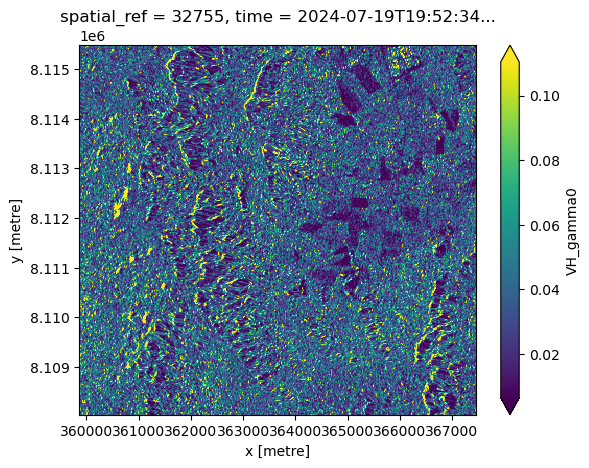

In [10]:
# Quickly plot to visualise the data
ds["VH_gamma0"].plot(robust = True)

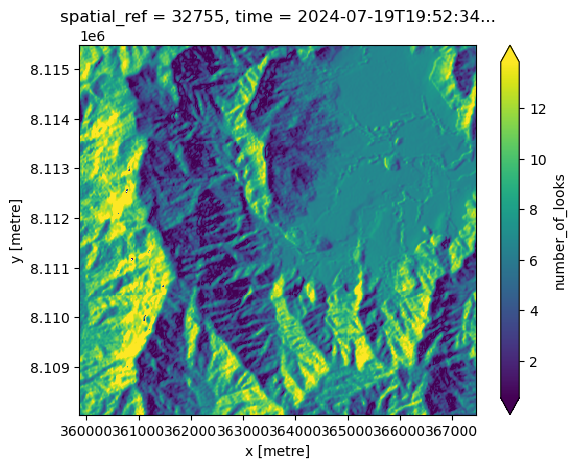

  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.
  boto3 not available, falling back to a DummySession.


In [ ]:
ds["number_of_looks"].plot(robust = True)

#### Lee Improved (enl = 7)
This cython code is sourced from the pyRAT library: https://github.com/birgander2/PyRAT

Lee's improved sigma speckle filter. Fast implementation in Cython.

        J.S. Lee et al.: Improved Sigma Filter for Speckle Filtering of SAR Imagery.
        IEEE Transactions on Geoscience and Remote Sensing, Vol. 47, No.1, pp. 202-213, 2009

        author: Andreas Reigber

Notes:
To install in terminal run:
git clone https://github.com/birgander2/PyRAT
cd PyRAT
pip install .
conda env create -f requirements.txt -n pyrat
conda activate pyrat 

You may also need to run:
sudo apt-get update
sudo apt-get install libfftw3-dev
sudo apt-get install liblapack-dev libblas-dev gfortran

You may need to downgrade NumPy:
Make sure conda env is active
        conda activate pyrat
Uninstall current NumPy (probably 2.x)
        pip uninstall -y numpy
Install a compatible NumPy 1.x (e.g. 1.26.x, latest before 2.0)
        pip install "numpy<2.0"



In [12]:
import numpy as np
from pyrat.filter import cy_leeimproved 

/home/ubuntu/miniforge3/envs/pyrat/lib/python3.12/site-packages/pyrat/lib/ste/ste_io.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string
  
  Welcome to PyRAT (v0.65+oss)
  OS detected : linux
  Temporary directory: /tmp
  Pool with 8 workers initialised

  help() will show a list of available commands!


In [13]:
### Some data engineering to convert to a NumPy array for cython, and set up some expected dummy dimentions
arr = ds.VH_gamma0.data  # gives a dask array

# compute it to get a NumPy array in memory
arr_np = arr.compute()  # shape (y, x)
# original SAR array: arr_np (y, x)
mask = np.isnan(arr_np)
arr_np = np.nan_to_num(arr_np, nan=0.0).astype(np.float32)  # replace NaN with 0


In [14]:
# span is just intensity (y, x)
span = np.abs(arr_np).astype(np.float32)  # shape (668, 464)

span = np.squeeze(span).astype(np.float32)              # (13343, 9256)
# add dummy axes for nv, nz
array_for_cy = arr_np[np.newaxis, :, :]  # shape (1, 1, 668, 464)
# make sure contiguous
span = np.ascontiguousarray(span)
array_for_cy = np.ascontiguousarray(array_for_cy)

In [15]:
# call cython filter
out = cy_leeimproved(
    span=span,
    array=array_for_cy,
    win=(9,9),
    looks=7
)

In [16]:
# restore mask
out[0,mask] = np.nan

print("Output shape:", out.shape)  # should be (1, 1, 668, 464)

Output shape: (1, 1, 372, 380)


In [17]:
import xarray as xr

filtered_ds = xr.DataArray(
    out[0,0,:,:],  # remove dummy axes
    coords={"y": ds.y, "x": ds.x},
    dims=["y", "x"]
)


#### Lee sigma enhanced/improved (adaptive multilooking)
This is a test adaption of the cython PyRAT code, fully contained in python, that works by using the nlooks data layer, rather than a constant enl. 

Disclaimer: the code was written by ChatGPT

In [18]:
import numpy as np
import rasterio
import sys
sys.path.insert(1,'../../src/')
from lee_sigma_improved_xr import lee_sigma_improved_xr  # import the function we wrote

In [28]:
# --- Apply the filter ---
lee_improved_adapt_filtered = lee_sigma_improved_xr(
    ds, 
    'VH_gamma0',
    'number_of_looks', 
    data_type = 'intensity',
    win=(9, 9)
)

#### Cython adaption for Lee Enhanced/Improved (adaptive ML)


In [20]:
# from lee_adaptive import cy_leeimproved_adaptive

In [21]:
# import numpy as np
# from lee_adaptive import cy_leeimproved_adaptive
# import numpy as np
# import scipy as sp 
# import scipy.optimize as spopt

# def optf_for_bounds(i, looks, sigma):
#     i1, i2 = i
#     # sigmarange and intmean functions from your previous code
#     val = sp.integrate.quad(lambda x: (looks ** looks * x**(looks-1) / np.math.gamma(looks) * np.exp(-looks*x)), i1, i2)[0]
#     mean = sp.integrate.quad(lambda x: (looks ** looks * x**(looks-1) / np.math.gamma(looks) * np.exp(-looks*x)) * x, i1, i2)[0] / val
#     return (val - sigma)**2 + (mean - 1.0)**2

# def sigpdf(i, looks):
#     return (i - 1.0)**2 * (looks ** looks * i**(looks-1) / np.math.gamma(looks) * np.exp(-looks*i))



In [22]:
# # extract the SAR band and the looks band
# sar_da = ds['VH_gamma0']          # your SAR band
# looks_da = ds['number_of_looks']  # per-pixel number of looks

# # handle single time slice if present
# if 'time' in sar_da.dims:
#     sar_da = sar_da.isel(time=0)
# if 'time' in looks_da.dims:
#     looks_da = looks_da.isel(time=0)


In [23]:
# # compute Dask arrays to in-memory NumPy arrays
# sar_np = sar_da.data.compute()      # shape (y, x)
# looks_np = looks_da.data.compute()  # shape (y, x)

# # mask NaNs and replace them with 0 (safe for filter)
# sar_np = np.nan_to_num(sar_np, nan=0.0).astype(np.float32)
# looks_np = np.nan_to_num(looks_np, nan=1.0).astype(np.float32)

In [24]:
# # intensity (or amplitude squared)
# span = np.abs(sar_np).astype(np.float32)  # shape (y, x)

# # add dummy axes to match cython expectation (nv=1, nz=1)
# array_for_cy = sar_np[np.newaxis, np.newaxis, :, :]  # shape (1,1,y,x)

# # make arrays contiguous for Cython
# span = np.ascontiguousarray(span)
# array_for_cy = np.ascontiguousarray(array_for_cy)
# looks_np = np.ascontiguousarray(looks_np)


In [25]:
# # Round looks to nearest 0.5
# looks_rounded = np.round(looks_np * 2) / 2.0  # e.g., 1.23 → 1.0, 1.76 → 2.0

# # Unique rounded looks
# unique_looks = np.unique(looks_rounded)

# # Precompute bounds for each unique rounded look
# bounds_lookup = {}
# for lk in unique_looks:
#     try:
#         bounds_lookup[lk] = spopt.fmin(optf_for_bounds, [0.5, 2.0], args=(lk, 0.9), disp=False)
#     except:
#         bounds_lookup[lk] = [0.5, 2.0]

# # Assign per-pixel bounds using the rounded values
# ny, nx = looks_np.shape
# bounds_arr = np.zeros((2, ny, nx), dtype=np.float32)
# for k in range(ny):
#     for l in range(nx):
#         bounds_arr[:, k, l] = bounds_lookup[looks_rounded[k, l]]

In [26]:
# # Precompute per-pixel newsig
# newsig_arr = np.zeros((ny, nx), dtype=np.float32)
# newsig_lookup = {}
# for lk in unique_looks:
#     # Find pixels with this rounded looks
#     mask = looks_rounded == lk
#     # Use bounds from bounds_arr for this pixels (average bounds for safety)
#     i1 = np.mean(bounds_arr[0][mask])
#     i2 = np.mean(bounds_arr[1][mask])
#     try:
#         newsig_lookup[lk] = (1.0 / 0.9) * sp.integrate.quad(sigpdf, i1, i2, args=(lk,))[0]
#     except Exception:
#         newsig_lookup[lk] = 0.5

# # Assign per-pixel newsig using rounded looks
# newsig_arr = np.vectorize(lambda lk: newsig_lookup[lk])(looks_rounded)

In [27]:
# # run the cython function/apply adaptive speckle filter
# out = cy_leeimproved_adaptive(span, array_for_cy, looks_np, bounds_arr=bounds_arr, newsig_arr=newsig_arr)

In [28]:
# # Optional: batch multiple bands or time slices
# for t in range(num_times):
#     array_for_cy = ds['VH_gamma0'].isel(time=t).data.compute()[np.newaxis, np.newaxis, :, :]
#     looks_np = ds['number_of_looks'].isel(time=t).data.compute()
#     # call your cython filter here


#### Load in CSIRO filtered product for visualisation
Loading in the CSIRO filtered product to compare against the new speckle filtered algorithms which are applied as post-processing steps. The CSIRO product is cropped to the same region of interest.

In [20]:
import shapely.geometry as geom
import geopandas as gpd
import rioxarray

# open geotiff
geo_da = rioxarray.open_rasterio("/home/ubuntu/exploratory_data_analysis/data/DT/S1A_IW_GRDH_1SDV_20240719T195220_20240719T195245_054834_06AD81_A14E_gamma0_vh_20m.tif")

# define ROI in WGS84 (lon/lat)
roi_box_wgs84 = roi_box

# convert to polygon in WGS84
roi_poly = geom.box(*roi_box_wgs84)
roi_gdf = gpd.GeoDataFrame({"geometry": [roi_poly]}, crs="EPSG:4326")

# reproject ROI into geotiff CRS
roi_gdf_proj = roi_gdf.to_crs(geo_da.rio.crs)

# crop geotiff
cropped_geo = geo_da.rio.clip(roi_gdf_proj.geometry, roi_gdf_proj.crs).squeeze()


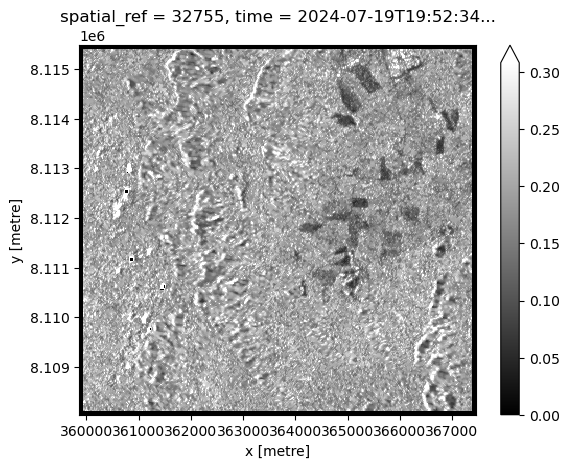

In [24]:
lee_improved_adapt_filtered.plot.imshow(cmap="gray", robust = True)

In [22]:
unfiltered_ds = ds['VH_gamma0'].isel(time=0)

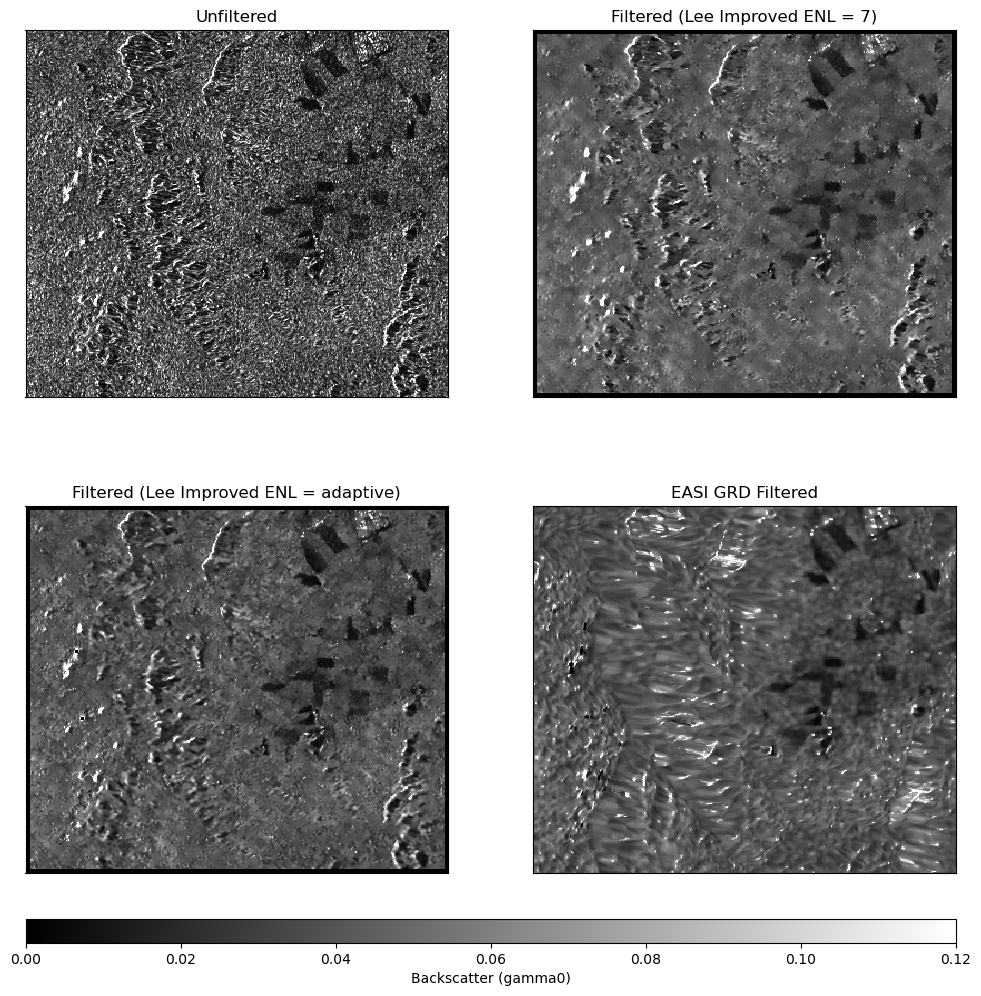

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

vmin, vmax = 0, 0.12

# plot each dataset without individual colorbars
unfiltered_ds.plot.imshow(ax=axes[0], cmap="gray", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[0].set_title("Unfiltered")

filtered_ds.plot.imshow(ax=axes[1], cmap="gray", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[1].set_title("Filtered (Lee Improved ENL = 7)")

lee_improved_adapt_filtered.plot.imshow(ax=axes[2], cmap="gray", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[2].set_title("Filtered (Lee Improved ENL = adaptive)")

cropped_geo.plot.imshow(ax=axes[3], cmap="gray", vmin=vmin, vmax=vmax, add_colorbar=False)
axes[3].set_title("EASI GRD Filtered")

# remove axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

# adjust layout to make room for the colorbar
fig.subplots_adjust(bottom=0.1, hspace=0.3)

# one shared colorbar at bottom
cbar = fig.colorbar(
    axes[0].images[0], ax=axes, orientation="horizontal",
    fraction=0.05, pad=0.05, aspect=40
)
cbar.set_label("Backscatter (gamma0)")

plt.show()
